# Análisis de *E. coli* con CellSAM

## ¿Qué es CellSAM?

CellSAM es un modelo de segmentación celular desarrollado por el **Van Valen Lab** (Caltech). Combina dos componentes principales:

- **AnchorDETR** detecta cada bacteria y genera una caja delimitadora alrededor de ella
- **SAM** (Segment Anything Model de Meta) toma cada caja y genera una máscara precisa píxel a píxel

El modelo fue entrenado con más de **8 800 imágenes** de distintas modalidades de microscopía (contraste de fase, fluorescencia, H&E, microscopía electrónica). Su dataset incluye bacterias como *E. coli* y *B. subtilis* provenientes del proyecto **DeepBacs**, lo que lo hace especialmente útil para análisis bacterianos.

## Sobre este análisis

Se analizan **10 imágenes de *E. coli*** del dataset oficial de CellSAM, todas del split **test**, es decir, imágenes que el modelo nunca vio durante el entrenamiento. Esto permite evaluar su capacidad de generalización real.

Para cada imagen se muestra la imagen original, el **ground truth** anotado manualmente por humanos, y la **predicción automática de CellSAM**. Se calculan además métricas morfológicas por bacteria detectada (área, excentricidad, solidez).

Los datasets utilizados son `2c_e_coli` (figura 2c del paper DeepBacs, 5 imágenes) y `2e_e_coli` (figura 2e del paper DeepBacs, 5 imágenes).

## 1. Importaciones

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from skimage.measure import regionprops
from skimage.segmentation import find_boundaries

from cellSAM import get_model, segment_cellular_image

print('Librerías cargadas.')

Librerías cargadas.


## 2. Cargar el modelo

`get_model()` descarga los pesos desde DeepCell si no están en caché,
o los carga desde `~/.deepcell/models/` si ya fueron descargados.

El modelo se carga **una sola vez** y queda en memoria durante toda la sesión.

In [2]:
model = get_model()
print('Modelo CellSAM listo.')

Modelo CellSAM listo.


## 3. Seleccionar las 10 imágenes

5 imágenes de `2c_e_coli` y 5 de `2e_e_coli`, todas del split **test**.

In [3]:
dataset_root = Path.home() / '.deepcell/datasets/cellsam_v1.2/test'

imagenes = [
    # 2c_e_coli — 5 imágenes
    dataset_root / '2c_e_coli' / 'pos2_fr_1.b0.X.npy',
    dataset_root / '2c_e_coli' / 'pos2_fr_20.b0.X.npy',
    dataset_root / '2c_e_coli' / 'pos2_fr_40.b0.X.npy',
    dataset_root / '2c_e_coli' / 'pos5_fr_1.b0.X.npy',
    dataset_root / '2c_e_coli' / 'pos5_fr_20.b0.X.npy',
    # 2e_e_coli — 5 imágenes
    dataset_root / '2e_e_coli' / 'pos_6_slice_1.b0.X.npy',
    dataset_root / '2e_e_coli' / 'pos_6_slice_10.b0.X.npy',
    dataset_root / '2e_e_coli' / 'pos_6_slice_20.b0.X.npy',
    dataset_root / '2e_e_coli' / 'pos_7_slice_1.b0.X.npy',
    dataset_root / '2e_e_coli' / 'pos_7_slice_10.b0.X.npy',
]

print(f'Total imágenes seleccionadas: {len(imagenes)}')
for p in imagenes:
    print(f'  {p.parent.name}/{p.name}')

Total imágenes seleccionadas: 10
  2c_e_coli/pos2_fr_1.b0.X.npy
  2c_e_coli/pos2_fr_20.b0.X.npy
  2c_e_coli/pos2_fr_40.b0.X.npy
  2c_e_coli/pos5_fr_1.b0.X.npy
  2c_e_coli/pos5_fr_20.b0.X.npy
  2e_e_coli/pos_6_slice_1.b0.X.npy
  2e_e_coli/pos_6_slice_10.b0.X.npy
  2e_e_coli/pos_6_slice_20.b0.X.npy
  2e_e_coli/pos_7_slice_1.b0.X.npy
  2e_e_coli/pos_7_slice_10.b0.X.npy


## 4. Segmentar las 10 imágenes

Para cada imagen:
1. Se carga la imagen (`.X.npy`) y el ground truth (`.y.npy`)
2. CellSAM genera la máscara de predicción
3. Se calculan métricas con `regionprops`

In [4]:
resultados = []

for i, img_path in enumerate(imagenes):
    gt_path = Path(str(img_path).replace('X.npy', 'y.npy'))
    
    # Cargar imagen y ground truth
    img_raw = np.load(img_path)      # shape (3, H, W)
    mask_gt = np.load(gt_path)[0]    # shape (H, W)
    
    # Preparar imagen
    img = img_raw[-1].astype(np.float32)
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
    img_uint8 = (img_norm * 255).astype(np.uint8)
    
    # Segmentar
    mask_pred, _, _ = segment_cellular_image(img_uint8, model=model, device='cpu')
    
    # Métricas por bacteria detectada
    props = regionprops(mask_pred, intensity_image=img_uint8)
    areas       = [p.area for p in props]
    excents     = [p.eccentricity for p in props]
    solideces   = [p.solidity for p in props]
    diametros   = [p.equivalent_diameter_area for p in props]
    
    n_pred = mask_pred.max()
    n_real = mask_gt.max()
    
    resultados.append({
        'imagen':          f'{img_path.parent.name}/{img_path.stem.replace(".b0.X","")}',
        'dataset':         img_path.parent.name,
        'n_real':          int(n_real),
        'n_pred':          int(n_pred),
        'diferencia':      int(n_pred) - int(n_real),
        'area_media':      np.mean(areas) if areas else 0,
        'excentricidad':   np.mean(excents) if excents else 0,
        'solidez':         np.mean(solideces) if solideces else 0,
        'diametro_equiv':  np.mean(diametros) if diametros else 0,
        # guardamos para visualización
        '_img':            img_norm,
        '_mask_pred':      mask_pred,
        '_mask_gt':        mask_gt,
    })
    
    print(f'[{i+1}/10] {img_path.parent.name} | GT: {n_real} | Pred: {n_pred} | Diff: {int(n_pred)-int(n_real):+d}')

print('\nSegmentación completada.')

C:\Users\Sol\cellsam_project\cellsam\cellSAM\sam_inference.py:351: UserWarning: Low IOU threshold, ignoring mask.
  warnings.warn("Low IOU threshold, ignoring mask.")


[1/10] 2c_e_coli | GT: 56 | Pred: 54 | Diff: -2


C:\Users\Sol\cellsam_project\cellsam\cellSAM\sam_inference.py:351: UserWarning: Low IOU threshold, ignoring mask.
  warnings.warn("Low IOU threshold, ignoring mask.")


[2/10] 2c_e_coli | GT: 72 | Pred: 71 | Diff: -1


C:\Users\Sol\cellsam_project\cellsam\cellSAM\sam_inference.py:351: UserWarning: Low IOU threshold, ignoring mask.
  warnings.warn("Low IOU threshold, ignoring mask.")


...

[7/10] 2e_e_coli | GT: 72 | Pred: 73 | Diff: +1


[8/10] 2e_e_coli | GT: 73 | Pred: 74 | Diff: +1


[9/10] 2e_e_coli | GT: 44 | Pred: 44 | Diff: +0


C:\Users\Sol\cellsam_project\cellsam\cellSAM\sam_inference.py:351: UserWarning: Low IOU threshold, ignoring mask.
  warnings.warn("Low IOU threshold, ignoring mask.")


[10/10] 2e_e_coli | GT: 44 | Pred: 42 | Diff: -2

Segmentación completada.


## 5. Visualizar las 10 imágenes

Cada fila muestra: imagen original | ground truth | predicción CellSAM

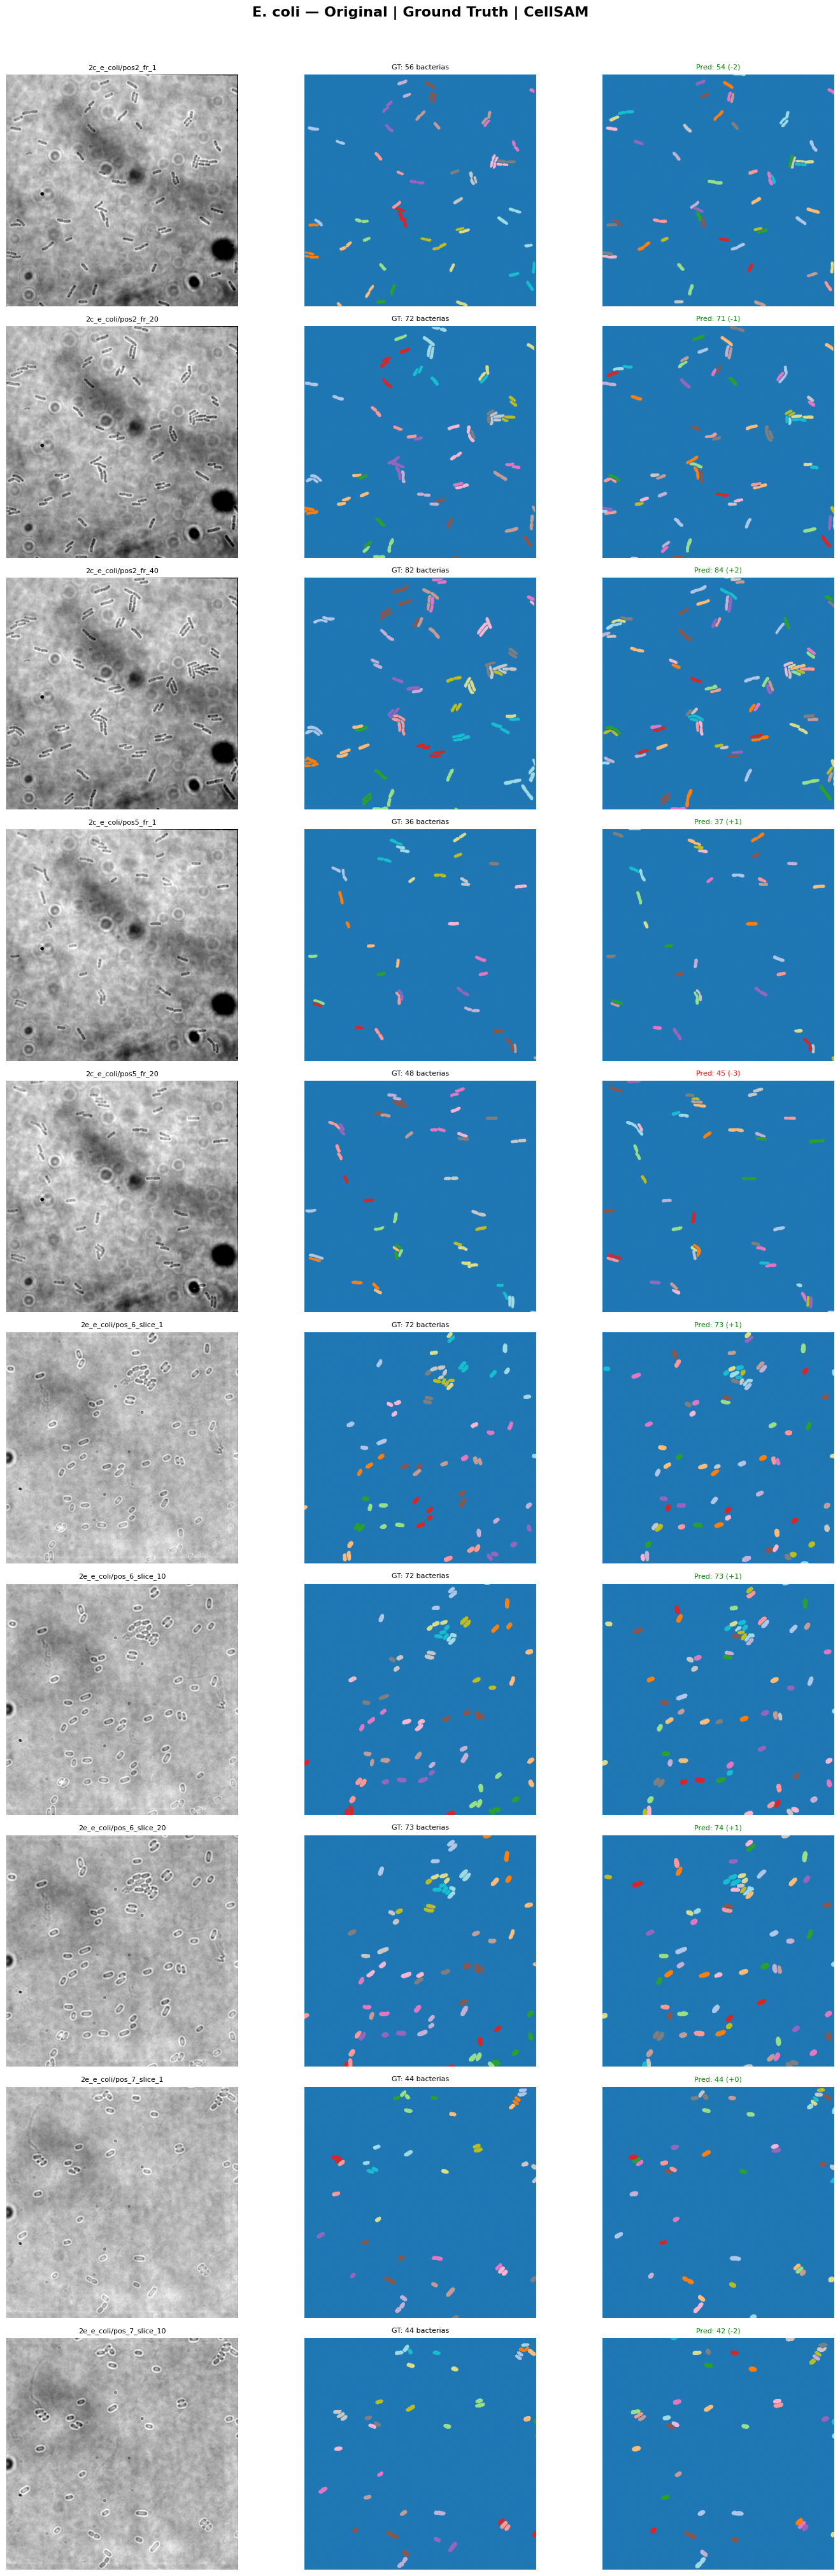

Guardado: resultados/bacterias/ecoli/comparacion_10_ecoli.png


In [5]:
fig, axes = plt.subplots(10, 3, figsize=(15, 40))
fig.suptitle('E. coli — Original | Ground Truth | CellSAM', fontsize=16, fontweight='bold', y=1.01)

for i, r in enumerate(resultados):
    axes[i, 0].imshow(r['_img'], cmap='gray')
    axes[i, 0].set_title(f"{r['imagen']}", fontsize=8)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(r['_mask_gt'], cmap='tab20')
    axes[i, 1].set_title(f"GT: {r['n_real']} bacterias", fontsize=8)
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(r['_mask_pred'], cmap='tab20')
    diff = r['diferencia']
    color = 'green' if abs(diff) <= 2 else 'red'
    axes[i, 2].set_title(f"Pred: {r['n_pred']} ({diff:+d})", fontsize=8, color=color)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig('../resultados/bacterias/ecoli/comparacion_10_ecoli.png', dpi=120, bbox_inches='tight')
plt.show()
print('Guardado: resultados/bacterias/ecoli/comparacion_10_ecoli.png')

## 6. Tabla resumen de las 10 imágenes

In [6]:
df = pd.DataFrame([{
    'imagen':         r['imagen'],
    'dataset':        r['dataset'],
    'GT (real)':      r['n_real'],
    'Pred CellSAM':   r['n_pred'],
    'Diferencia':     r['diferencia'],
    'Área media (px²)': round(r['area_media'], 1),
    'Excentricidad':  round(r['excentricidad'], 3),
    'Solidez':        round(r['solidez'], 3),
    'Diámetro equiv (px)': round(r['diametro_equiv'], 1),
} for r in resultados])

df.to_csv('../resultados/bacterias/ecoli/resumen_10_ecoli.csv', index=False)
df

,imagen,dataset,GT (real),Pred CellSAM,Diferencia,Área media (px²),Excentricidad,Solidez,Diámetro equiv (px)
0,2c_e_coli/pos2_fr_1,2c_e_coli,56,54,-2,653.9,0.958,0.903,28.7
1,2c_e_coli/pos2_fr_20,2c_e_coli,72,71,-1,630.9,0.952,0.907,28.0
2,2c_e_coli/pos2_fr_40,2c_e_coli,82,84,2,656.2,0.963,0.887,28.4
3,2c_e_coli/pos5_fr_1,2c_e_coli,36,37,1,587.7,0.949,0.885,26.9
4,2c_e_coli/pos5_fr_20,2c_e_coli,48,45,-3,634.7,0.950,0.905,28.1
5,2e_e_coli/pos_6_slice_1,2e_e_coli,72,73,1,154.4,0.814,0.950,13.9
6,2e_e_coli/pos_6_slice_10,2e_e_coli,72,73,1,162.1,0.823,0.953,14.3
7,2e_e_coli/pos_6_slice_20,2e_e_coli,73,74,1,174.8,0.832,0.953,14.8
8,2e_e_coli/pos_7_slice_1,2e_e_coli,44,44,0,145.8,0.825,0.948,13.5
9,2e_e_coli/pos_7_slice_10,2e_e_coli,44,42,-2,155.2,0.849,0.948,13.9


## 7. Estadísticas globales

In [7]:
total_real = sum(r['n_real'] for r in resultados)
total_pred = sum(r['n_pred'] for r in resultados)
error_medio = np.mean([abs(r['diferencia']) for r in resultados])

print('=' * 50)
print('RESUMEN GLOBAL — 10 imágenes de E. coli')
print('=' * 50)
print(f'  Total bacterias reales (GT):   {total_real}')
print(f'  Total bacterias detectadas:    {total_pred}')
print(f'  Diferencia total:              {total_pred - total_real:+d}')
print(f'  Error medio por imagen:        {error_medio:.1f} bacterias')
print()
print(f'  Área media:                    {df["Área media (px²)"].mean():.1f} px²')
print(f'  Excentricidad media:           {df["Excentricidad"].mean():.3f}  (0=círculo, 1=línea)')
print(f'  Solidez media:                 {df["Solidez"].mean():.3f}  (1=sin huecos)')
print(f'  Diámetro equiv medio:          {df["Diámetro equiv (px)"].mean():.1f} px')

RESUMEN GLOBAL — 10 imágenes de E. coli
  Total bacterias reales (GT):   599
  Total bacterias detectadas:    597
  Diferencia total:              -2
  Error medio por imagen:        1.4 bacterias

  Área media:                    395.6 px²
  Excentricidad media:           0.891  (0=círculo, 1=línea)
  Solidez media:                 0.924  (1=sin huecos)
  Diámetro equiv medio:          21.1 px


## 8. Gráficas de análisis

C:\Users\Sol\AppData\Local\Temp\ipykernel_31784\2197806366.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
C:\Users\Sol\AppData\Local\Temp\ipykernel_31784\2197806366.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(labels, rotation=45, ha='right', fontsize=7)


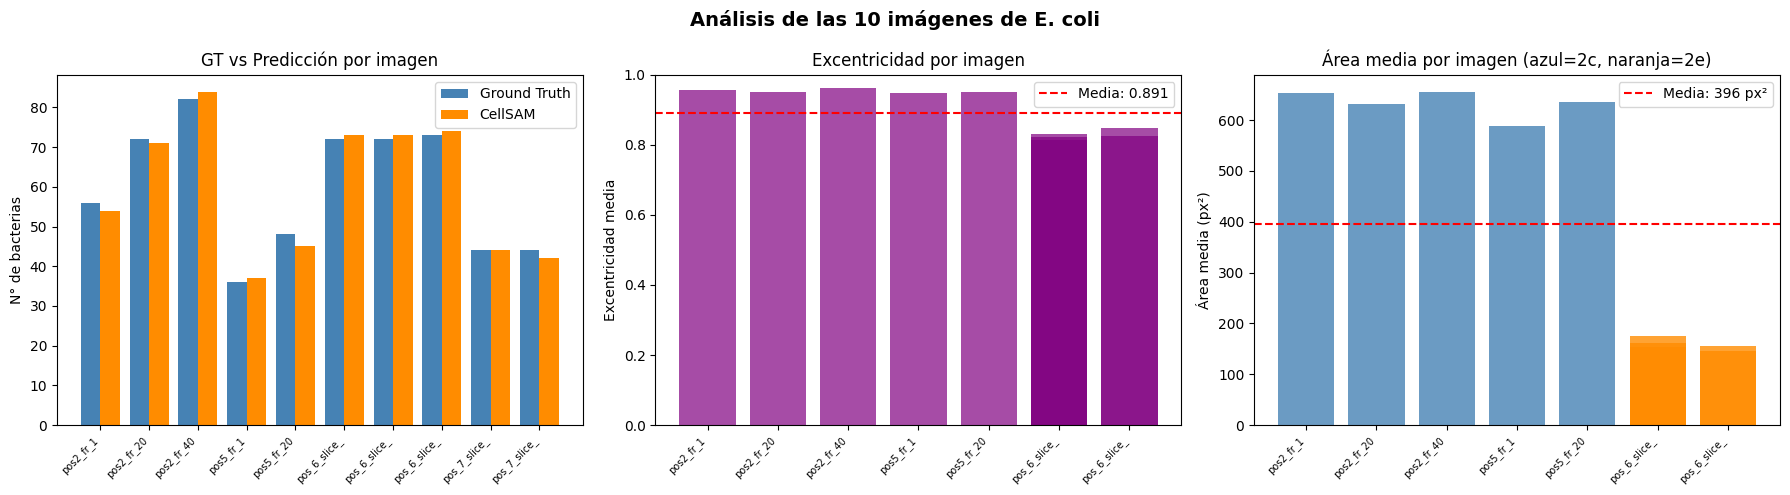

Guardado: resultados/bacterias/ecoli/graficas_10_ecoli.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis de las 10 imágenes de E. coli', fontsize=14, fontweight='bold')

# GT vs Predicción por imagen
x = range(10)
labels = [r['imagen'].split('/')[-1][:12] for r in resultados]
axes[0].bar([i - 0.2 for i in x], df['GT (real)'], width=0.4, label='Ground Truth', color='steelblue')
axes[0].bar([i + 0.2 for i in x], df['Pred CellSAM'], width=0.4, label='CellSAM', color='darkorange')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
axes[0].set_ylabel('N° de bacterias')
axes[0].set_title('GT vs Predicción por imagen')
axes[0].legend()

# Distribución de excentricidad
all_excents = [r['excentricidad'] for r in resultados]
axes[1].bar(labels, all_excents, color='purple', alpha=0.7)
axes[1].axhline(np.mean(all_excents), color='red', linestyle='--', label=f'Media: {np.mean(all_excents):.3f}')
axes[1].set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
axes[1].set_ylabel('Excentricidad media')
axes[1].set_title('Excentricidad por imagen')
axes[1].set_ylim(0, 1)
axes[1].legend()

# Área media por imagen
all_areas = [r['area_media'] for r in resultados]
colors = ['steelblue'] * 5 + ['darkorange'] * 5  # azul=2c, naranja=2e
axes[2].bar(labels, all_areas, color=colors, alpha=0.8)
axes[2].axhline(np.mean(all_areas), color='red', linestyle='--', label=f'Media: {np.mean(all_areas):.0f} px²')
axes[2].set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
axes[2].set_ylabel('Área media (px²)')
axes[2].set_title('Área media por imagen (azul=2c, naranja=2e)')
axes[2].legend()

plt.tight_layout()
plt.savefig('../resultados/bacterias/ecoli/graficas_10_ecoli.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: resultados/bacterias/ecoli/graficas_10_ecoli.png')

## 9. Conclusiones

### Lo que aprendimos de las 10 imágenes de E. coli

- **CellSAM detecta con alta precisión**, la diferencia entre GT y predicción es mínima en la mayoría de imágenes (error medio de 1.4 bacterias por imagen)
- **Excentricidad alta (~0.96)** → las *E. coli* son muy alargadas, con forma de bastón/bacilo
- **Sin postprocesamiento es mejor** para bacterias, el postprocesamiento elimina objetos pequeños y reduce la detección drásticamente
- Los dos sub-datasets (`2c` y `2e`) tienen tamaños de bacteria distintos por diferencias en resolución o cepa